# 15: FD001 Validation Report Assets

Este notebook usa solo validacion artificial. El test oficial no se utiliza.

Objetivo: generar tablas y visuales finales para cerrar la seleccion por validacion, sin entrenar modelos nuevos y sin leer ningun artefacto del test oficial.


## A. Carga de resultados de validacion


In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results" / "FD001"
FIGURE_DIR = PROJECT_ROOT / "figures" / "fd001_validation_final"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")


In [12]:
ranking = pd.read_csv(RESULTS_DIR / "fd001_final_validation_ranking.csv")
window_cap = pd.read_csv(RESULTS_DIR / "fd001_lgbm_window_cap_search.csv")
sample_weights = pd.read_csv(RESULTS_DIR / "fd001_lgbm_sample_weight_search.csv")
mlp_summary = pd.read_csv(RESULTS_DIR / "fd001_mlp_cfg03_seed_summary.csv")
mlp_stability = pd.read_csv(RESULTS_DIR / "fd001_mlp_cfg03_seed_stability.csv")
boosting = pd.read_csv(RESULTS_DIR / "fd001_boosting_metrics.csv")
lgbm_predictions = pd.read_csv(RESULTS_DIR / "fd001_lgbm_sample_weight_predictions.csv")
mlp_predictions = pd.read_csv(RESULTS_DIR / "fd001_mlp_cfg03_seed_predictions.csv")

print("Resultados de validacion cargados.")


Resultados de validacion cargados.


## B. Tabla resumen de modelos importantes


In [13]:
from src.fd001_experiment_utils import (
    first_match,
    mlp_summary_value,
    row_from_series,
    save_bar,
)

summary_rows = []
summary_rows.append(row_from_series(
    "Ridge baseline",
    first_match(ranking, model_name="Ridge", representation="temporal_w30"),
    "Linear baseline on temporal features",
))
summary_rows.append(row_from_series(
    "RandomForest baseline",
    first_match(ranking, model_name="RandomForestRegressor", representation="temporal_w30"),
    "Strong temporal baseline",
))
summary_rows.append(row_from_series(
    "XGBRegressor",
    first_match(boosting, model_name="XGBRegressor"),
    "Boosting candidate with good dangerous error",
))
summary_rows.append(row_from_series(
    "LGBM w30 cap125",
    first_match(boosting, model_name="LGBMRegressor"),
    "Initial LGBM at temporal_w30",
))
summary_rows.append(row_from_series(
    "LGBM w50 cap125 none",
    first_match(sample_weights, model_name="LGBMRegressor", window_size=50, rul_cap=125, sample_weight_scheme="none"),
    "Conservative alternative: lower dangerous error",
))
summary_rows.append(row_from_series(
    "LGBM w50 cap125 bin_weights",
    first_match(sample_weights, model_name="LGBMRegressor", window_size=50, rul_cap=125, sample_weight_scheme="bin_weights"),
    "Validation-selected candidate: best C-MAPSS score",
))
summary_rows.append(row_from_series(
    "MLP cfg03 historical",
    first_match(ranking, source="mlp_initial_search", model_name="MLP_tabular_cfg_03"),
    "Best MLP from initial search",
))
summary_rows.append({
    "model_label": "MLP cfg03 seed average",
    "representation": "temporal_w30",
    "window_size": 30,
    "rul_cap": 125,
    "sample_weight_scheme": "none",
    "mae": mlp_summary_value(mlp_summary, "mae"),
    "rmse": mlp_summary_value(mlp_summary, "rmse"),
    "r2": mlp_summary_value(mlp_summary, "r2"),
    "cmapss_score": mlp_summary_value(mlp_summary, "cmapss_score"),
    "dangerous_error_pct": mlp_summary_value(mlp_summary, "dangerous_error_pct"),
    "note": "Mean across seeds 0-4",
})

summary = pd.DataFrame(summary_rows)
summary.to_csv(RESULTS_DIR / "fd001_validation_summary_for_report.csv", index=False)
display(summary)


,model_label,representation,window_size,rul_cap,sample_weight_scheme,mae,rmse,r2,cmapss_score,dangerous_error_pct,note
0,Ridge baseline,temporal_w30,30.0,125,none,18.419013,23.133112,0.699604,1073.335072,17.171717,Linear baseline on temporal features
1,RandomForest baseline,temporal_w30,30.0,125,none,13.817341,17.912073,0.819898,580.933845,14.141414,Strong temporal baseline
2,XGBRegressor,temporal_w30,30.0,125,none,13.931649,17.238230,0.833194,418.575570,9.090909,Boosting candidate with good dangerous error
3,LGBM w30 cap125,temporal_w30,30.0,125,none,12.809901,16.517134,0.846858,397.315013,11.111111,Initial LGBM at temporal_w30
4,LGBM w50 cap125 none,temporal_w50,50.0,125,none,11.297658,14.428233,0.883144,261.005416,6.060606,Conservative alternative: lower dangerous error
5,LGBM w50 cap125 bin_weights,temporal_w50,50.0,125,bin_weights,11.194267,14.037945,0.889380,251.554310,7.070707,Validation-selected candidate: best C-MAPSS score
6,MLP cfg03 historical,temporal_w30,30.0,125,none,12.626827,17.051460,0.836789,449.529187,10.101010,Best MLP from initial search
7,MLP cfg03 seed average,temporal_w30,30.0,125,none,14.094047,18.600888,0.805433,598.897205,11.313131,Mean across seeds 0-4


## C. Visuales del modelo candidato


In [14]:
candidate_predictions = lgbm_predictions.loc[
    (lgbm_predictions["model_name"] == "LGBMRegressor")
    & (lgbm_predictions["representation"] == "temporal_w50")
    & (lgbm_predictions["sample_weight_scheme"] == "bin_weights")
].copy()

if candidate_predictions.empty:
    raise ValueError("No hay predicciones de validacion para LGBM temporal_w50 bin_weights.")

candidate_predictions[["unit", "cycle", "y_true_rul_raw", "y_pred_rul", "error", "abs_error", "rul_bin"]].head()


,unit,cycle,y_true_rul_raw,y_pred_rul,error,abs_error,rul_bin
99,1,52,140.0,122.041483,-17.958517,17.958517,90+
100,1,82,110.0,112.700555,2.700555,2.700555,90+
101,1,112,80.0,96.434527,16.434527,16.434527,60-90
102,1,142,50.0,59.642563,9.642563,9.642563,30-60
103,1,172,20.0,22.414005,2.414005,2.414005,0-30


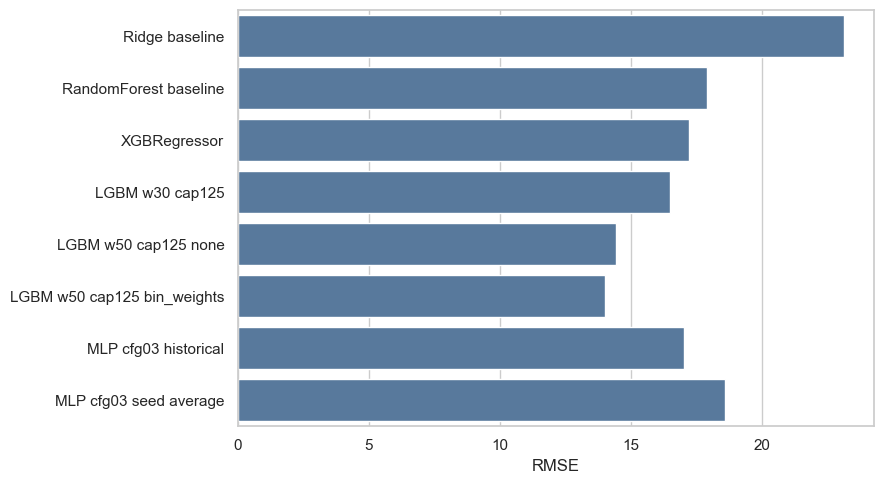

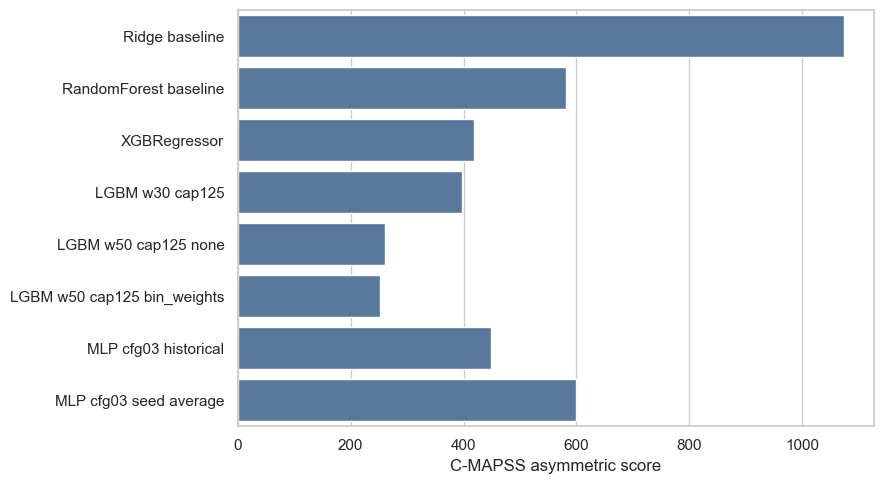

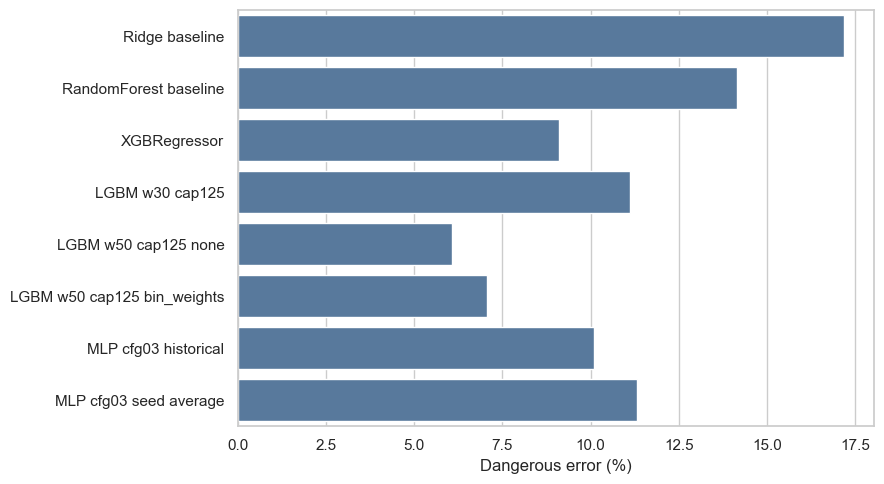

In [15]:
plot_order = [
    "Ridge baseline",
    "RandomForest baseline",
    "XGBRegressor",
    "LGBM w30 cap125",
    "LGBM w50 cap125 none",
    "LGBM w50 cap125 bin_weights",
    "MLP cfg03 historical",
    "MLP cfg03 seed average",
]
summary_plot = summary.set_index("model_label").loc[plot_order].reset_index()

save_bar(summary_plot, "rmse", FIGURE_DIR / "model_comparison_rmse.png", "RMSE", plt, sns)
save_bar(summary_plot, "cmapss_score", FIGURE_DIR / "model_comparison_cmapss_score.png", "C-MAPSS asymmetric score", plt, sns)
save_bar(summary_plot, "dangerous_error_pct", FIGURE_DIR / "model_comparison_dangerous_error.png", "Dangerous error (%)", plt, sns)


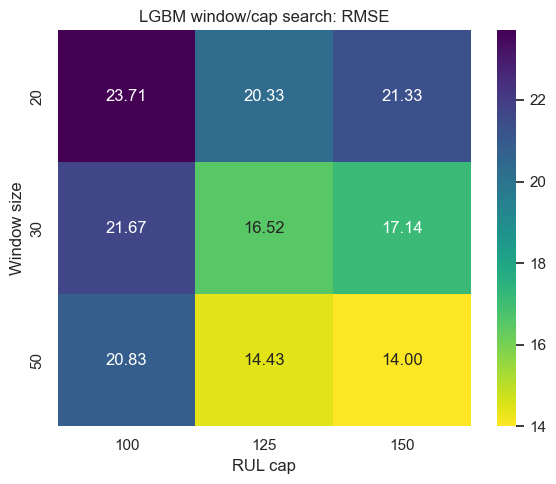

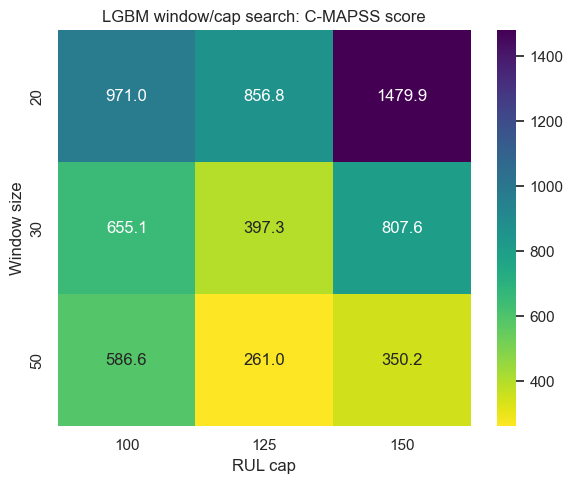

In [16]:
plt.figure(figsize=(6, 5))
heatmap_rmse = window_cap.pivot(index="window_size", columns="rul_cap", values="rmse")
sns.heatmap(heatmap_rmse, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("LGBM window/cap search: RMSE")
plt.xlabel("RUL cap")
plt.ylabel("Window size")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lgbm_window_cap_search_heatmap_rmse.png", dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(6, 5))
heatmap_score = window_cap.pivot(index="window_size", columns="rul_cap", values="cmapss_score")
sns.heatmap(heatmap_score, annot=True, fmt=".1f", cmap="viridis_r")
plt.title("LGBM window/cap search: C-MAPSS score")
plt.xlabel("RUL cap")
plt.ylabel("Window size")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lgbm_window_cap_search_heatmap_cmapss.png", dpi=150)
plt.show()
plt.close()


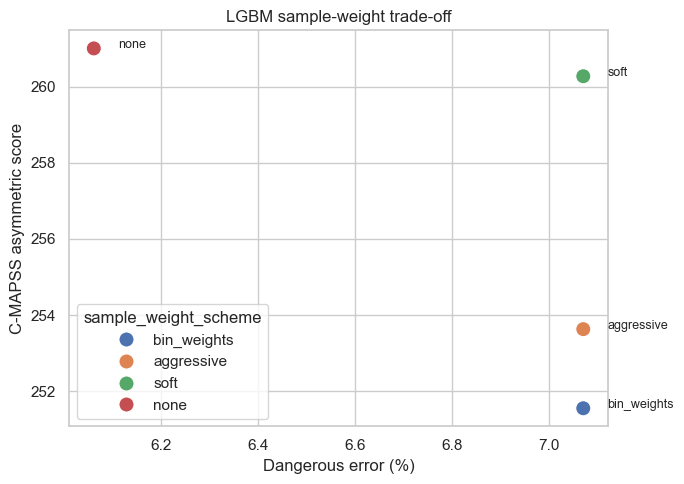

In [17]:
plt.figure(figsize=(7, 5))
tradeoff = sample_weights.copy()
sns.scatterplot(
    data=tradeoff,
    x="dangerous_error_pct",
    y="cmapss_score",
    hue="sample_weight_scheme",
    s=120,
)
for _, row in tradeoff.iterrows():
    plt.text(row["dangerous_error_pct"] + 0.05, row["cmapss_score"], row["sample_weight_scheme"], fontsize=9)
plt.xlabel("Dangerous error (%)")
plt.ylabel("C-MAPSS asymmetric score")
plt.title("LGBM sample-weight trade-off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lgbm_sample_weights_tradeoff.png", dpi=150)
plt.show()
plt.close()


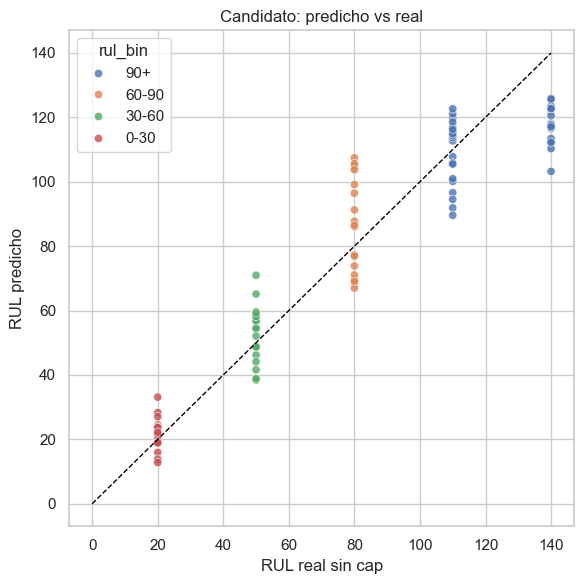

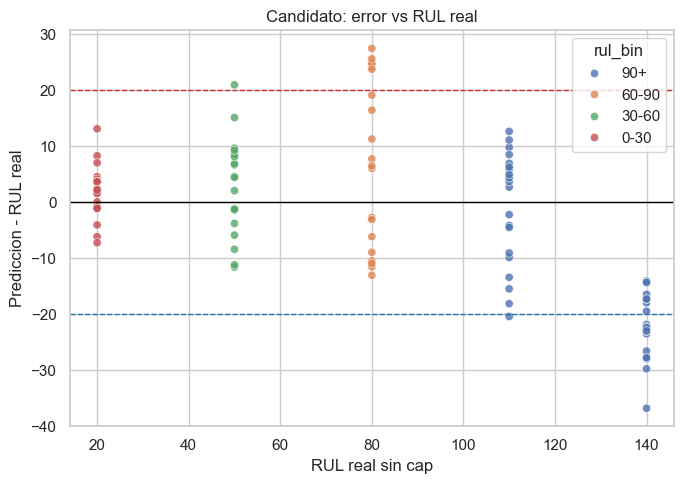

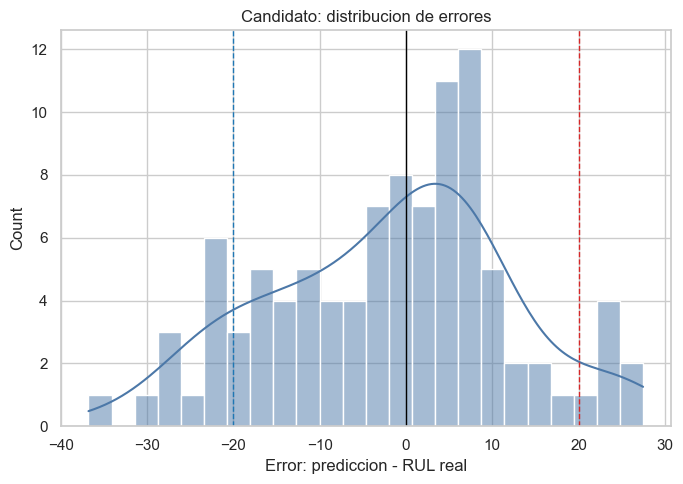

C:\Users\lauta\AppData\Local\Temp\ipykernel_25796\1219946112.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x="error_type", y="count", palette=["#D62728", "#1F77B4", "#59A14F"])


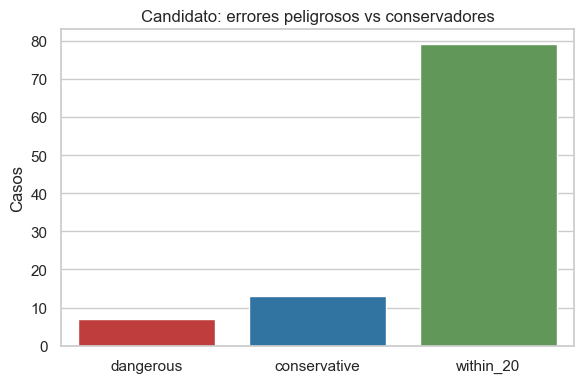

In [18]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=candidate_predictions, x="y_true_rul_raw", y="y_pred_rul", hue="rul_bin", alpha=0.8)
max_axis = max(candidate_predictions["y_true_rul_raw"].max(), candidate_predictions["y_pred_rul"].max())
plt.plot([0, max_axis], [0, max_axis], color="black", linestyle="--", linewidth=1)
plt.xlabel("RUL real sin cap")
plt.ylabel("RUL predicho")
plt.title("Candidato: predicho vs real")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "candidate_predicted_vs_true.png", dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=candidate_predictions, x="y_true_rul_raw", y="error", hue="rul_bin", alpha=0.8)
plt.axhline(0, color="black", linewidth=1)
plt.axhline(20, color="tab:red", linestyle="--", linewidth=1)
plt.axhline(-20, color="tab:blue", linestyle="--", linewidth=1)
plt.xlabel("RUL real sin cap")
plt.ylabel("Prediccion - RUL real")
plt.title("Candidato: error vs RUL real")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "candidate_error_vs_true_rul.png", dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(7, 5))
sns.histplot(candidate_predictions["error"], bins=24, kde=True, color="#4C78A8")
plt.axvline(0, color="black", linewidth=1)
plt.axvline(20, color="tab:red", linestyle="--", linewidth=1)
plt.axvline(-20, color="tab:blue", linestyle="--", linewidth=1)
plt.xlabel("Error: prediccion - RUL real")
plt.title("Candidato: distribucion de errores")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "candidate_error_distribution.png", dpi=150)
plt.show()
plt.close()

counts = pd.DataFrame({
    "error_type": ["dangerous", "conservative", "within_20"],
    "count": [
        int((candidate_predictions["error"] > 20).sum()),
        int((candidate_predictions["error"] < -20).sum()),
        int(((candidate_predictions["error"] <= 20) & (candidate_predictions["error"] >= -20)).sum()),
    ],
})
plt.figure(figsize=(6, 4))
sns.barplot(data=counts, x="error_type", y="count", palette=["#D62728", "#1F77B4", "#59A14F"])
plt.xlabel("")
plt.ylabel("Casos")
plt.title("Candidato: errores peligrosos vs conservadores")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "candidate_dangerous_vs_conservative.png", dpi=150)
plt.show()
plt.close()


## D. Trade-off bin_weights vs none


In [19]:
tradeoff_table = sample_weights.loc[
    sample_weights["sample_weight_scheme"].isin(["none", "bin_weights"])
].sort_values("sample_weight_scheme")
display(tradeoff_table[["sample_weight_scheme", "mae", "rmse", "r2", "cmapss_score", "dangerous_error_pct"]])


,sample_weight_scheme,mae,rmse,r2,cmapss_score,dangerous_error_pct
0,bin_weights,11.194267,14.037945,0.889380,251.554310,7.070707
3,none,11.297658,14.428233,0.883144,261.005416,6.060606


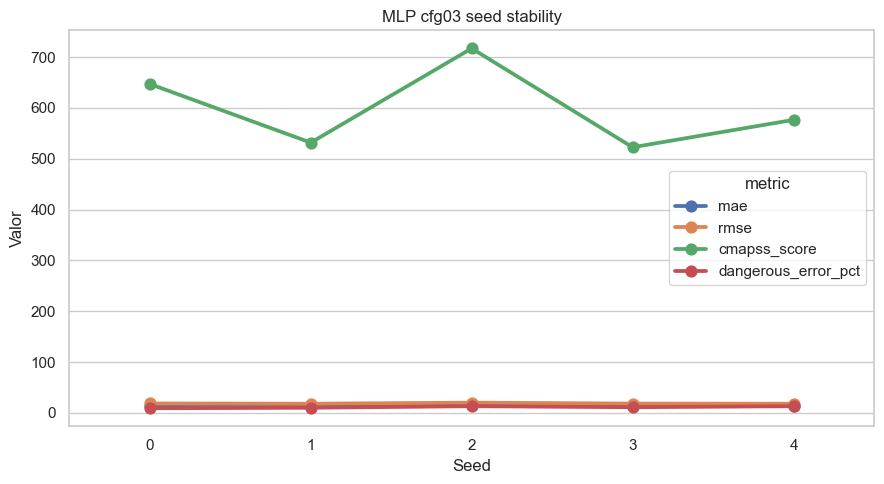

In [20]:
mlp_long = mlp_stability.melt(
    id_vars=["seed"],
    value_vars=["mae", "rmse", "cmapss_score", "dangerous_error_pct"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(9, 5))
sns.pointplot(data=mlp_long, x="seed", y="value", hue="metric", errorbar=None)
plt.title("MLP cfg03 seed stability")
plt.xlabel("Seed")
plt.ylabel("Valor")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "mlp_seed_stability.png", dpi=150)
plt.show()
plt.close()


## E. Conclusiones cortas

- LGBM w50 cap125 mejora claramente sobre w30 en validacion artificial.
- Sample weights reducen C-MAPSS score pero aumentan levemente dangerous error.
- MLP cfg03 no fue estable entre seeds.
- El candidato final por validacion es LGBM w50 cap125 bin_weights.
- La alternativa conservadora es LGBM w50 cap125 sin pesos.